In [ ]:
!pip install pymysql
!pip install sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
# Connection details
hostname = "SOMEHOSTNAME" #'<CompanyName>-mysql-rds-2.<ID>.us-east-1.rds.amazonaws.com' #prod
port = 3306  # default MySQL port
username = 'SOMEUSERNAME'
password = 'PASSWORD'

In [ ]:
from sqlalchemy import create_engine, inspect, MetaData, Table
database = "YOURDATABASENAME"

# Create the engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{hostname}:{port}/{database}")

In [ ]:
from sqlalchemy.sql import text

with engine.connect() as con:
    statement = text("""
     SELECT player_name, AVG(strike_rate) AS average_strike_rate
FROM batting_score
WHERE player_name LIKE '%Aaron Jones%'
AND tournament_name LIKE '%Houston Open 2025%'
GROUP BY player_name
LIMIT 5;
    """)
    result = con.execute(statement)
    rows = result.fetchall()
    columns = result.keys()
    print("Columns:", columns)
    for row in rows:
      print(row)

Columns: RMKeyView(['player_name', 'average_strike_rate'])
('Aaron Jones', 103.26666641235352)


In [ ]:
from sqlalchemy.sql import text

with engine.connect() as con:
    statement = text("""
     SELECT DISTINCT *
FROM batting_score
WHERE tournament_name LIKE '%Baroda%'
OR league_name LIKE '%Baroda%'
LIMIT 5;
    """)
    result = con.execute(statement)
    rows = result.fetchall()
    columns = result.keys()
    print("Columns:", columns)
    for row in rows:
      print(row)

Columns: RMKeyView(['batting_score_id', 'matchId', 'match_date', 'tournament_start_date', 'tournament_end_date', 'match_year', 'tournament_name', 'city', 'match_ground', 'league_name', 'state', 'match_country', 'innings_played', 'winning_team_name', 'losing_team_name', 'player_team_name', 'played_against_team_name', 'player_name', 'batsman_style', 'bowling_style', 'player_role', 'runs_scored', 'fours', 'six', 'strike_rate', 'balls_faced', 'one', 'two', 'three', 'dotBall', 'dismissal_type', 'dismissed_bowler_name', 'dismissed_bowler_style', 'fall_of_wickets', 'dismissed_bowler_kind', 'wicket_ball_variation', 'wicket_ball_line', 'wicket_ball_length', 'wicket_ball_shot', 'wicket_shot_direction', 'player_order', 'player_in_over', 'player_out_over'])


In [ ]:
from sqlalchemy.sql import text

with engine.connect() as con:
    statement = text("""
        SELECT player_name, strike_rate
        FROM batting_score
        WHERE player_name LIKE '%Aaron Jones%'
        AND tournament_name LIKE '%Houston Open 2025%'
    """)
    result = con.execute(statement)
    rows = result.fetchall()
    columns = result.keys()
    print("Columns:", columns)
    for row in rows:
        print(row)


Columns: RMKeyView(['player_name', 'strike_rate'])
('Aaron Jones', 165.0)
('Aaron Jones', 53.3333)
('Aaron Jones', 188.0)
('Aaron Jones', 40.0)
('Aaron Jones', 70.0)


In [ ]:
# SQL Query to Select Data from the View
query = """
    SELECT * FROM view_player_performance LIMIT 10;
"""

# Execute the Query
try:
    with engine.connect() as connection:
        result = connection.execute(text(query))
        rows = result.fetchall()
        columns = result.keys()
        # Display Results
        print("Columns:", columns)
        for row in rows:
            print(row)
except Exception as e:
    print("Error:", str(e))

Columns: RMKeyView(['playerId', 'player_name', 'playerRole', 'gender', 'DOB', 'matchId', 'match_date', 'match_location', 'match_type', 'winning_team', 'losing_team', 'is_draw', 'batting_runs', 'batting_fours', 'batting_sixes', 'batting_strike_rate', 'dot_balls', 'balls_faced', 'bowling_wickets', 'bowling_economy', 'maiden_overs', 'runs_given', 'overs_bowled', 'career_matches', 'career_runs', 'career_strike_rate', 'batting_average', 'career_wickets', 'career_economy', 'bowling_average', 'career_five_wickets'])
('', None, None, None, None, None, None, None, None, None, None, None, 0, 0, 0, 0.0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0.0, 0.0, 0, 0.0, 0.0, 0)
('00005952-741c-4a95-b096-0f9db8704644', 'Diego Godín', 'PLAYER', None, None, None, None, None, None, None, None, None, 0, 0, 0, 0.0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0.0, 0.0, 0, 0.0, 0.0, 0)
('000b05fb-c8af-4f26-8fe2-40924deb8b53', 'Hardik Pandya', None, None, None, None, None, None, None, None, None, None, 16, 0, 0, 133.33333333333334, 2, 12, 0

In [ ]:
# SQL Query to Select Data from the View
query = """
    SELECT * FROM view_player_performance WHERE player_name LIKE "KL RAHUL";
"""

# Execute the Query
try:
    with engine.connect() as connection:
        result = connection.execute(text(query))
        rows = result.fetchall()
        columns = result.keys()
        # Display Results
        print("Columns:", columns)
        for row in rows:
            print(row)
except Exception as e:
    print("Error:", str(e))

Columns: RMKeyView(['playerId', 'player_name', 'playerRole', 'gender', 'DOB', 'matchId', 'match_date', 'match_location', 'match_type', 'winning_team', 'losing_team', 'is_draw', 'batting_runs', 'batting_fours', 'batting_sixes', 'batting_strike_rate', 'dot_balls', 'balls_faced', 'bowling_wickets', 'bowling_economy', 'maiden_overs', 'runs_given', 'overs_bowled', 'career_matches', 'career_runs', 'career_strike_rate', 'batting_average', 'career_wickets', 'career_economy', 'bowling_average', 'career_five_wickets'])
('040122ca-4ec6-4584-bee1-f169e04cebd8', 'KL Rahul', 'PLAYER', None, None, None, None, None, None, None, None, None, 0, 0, 0, 0.0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0.0, 0.0, 0, 0.0, 0.0, 0)
('131791b1-44fd-4ea4-919a-087ceb0fd659', 'kl rahul', None, None, None, None, None, None, None, None, None, None, 0, 0, 0, 0.0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0.0, 0.0, 0, 0.0, 0.0, 0)
('19f3df32-ec4c-468a-9ea3-a23e2e3486d5', 'KL Rahul', None, None, None, None, None, None, None, None, None, None, 0, 0

In [ ]:
# SQL Query to Select Data from the View
query = """
    SELECT * FROM view_player_performance WHERE player_name LIKE "Hardik Pandya";
"""

# Execute the Query
try:
    with engine.connect() as connection:
        result = connection.execute(text(query))
        rows = result.fetchall()
        columns = result.keys()
        # Display Results
        print("Columns:", columns)
        for row in rows:
            print(row)
except Exception as e:
    print("Error:", str(e))

Columns: RMKeyView(['playerId', 'player_name', 'playerRole', 'gender', 'DOB', 'matchId', 'match_date', 'match_location', 'match_type', 'winning_team', 'losing_team', 'is_draw', 'batting_runs', 'batting_fours', 'batting_sixes', 'batting_strike_rate', 'dot_balls', 'balls_faced', 'bowling_wickets', 'bowling_economy', 'maiden_overs', 'runs_given', 'overs_bowled', 'career_matches', 'career_runs', 'career_strike_rate', 'batting_average', 'career_wickets', 'career_economy', 'bowling_average', 'career_five_wickets'])
('000b05fb-c8af-4f26-8fe2-40924deb8b53', 'Hardik Pandya', None, None, None, None, None, None, None, None, None, None, 16, 0, 0, 133.33333333333334, 2, 12, 0, 6.0, 0, 2, 0, 0, 0, 0.0, 0.0, 0, 0.0, 0.0, 0)
('1df58783-e072-4926-a0dc-7c406006a6d5', 'Hardik Pandya', None, None, None, None, None, None, None, None, None, None, 0, 0, 0, 0.0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0.0, 0.0, 0, 0.0, 0.0, 0)
('25866267-1d7c-499c-b4b0-6b324aa4e423', 'Hardik Pandya', None, None, None, None, None, None, 

In [ ]:
# SQL Query to Select Data from the View
query = """
    SELECT * FROM `Balls` LIMIT 10;
"""

# Execute the Query
try:
    with engine.connect() as connection:
        result = connection.execute(text(query))
        rows = result.fetchall()
        columns = result.keys()
        # Display Results
        print("Columns:", columns)
        for row in rows:
            print(row)
except Exception as e:
    print("Error:", str(e))

Columns: RMKeyView(['ball_id', 'matchId', 'over_number', 'ball_number', 'runs_scored', 'batsmanId', 'bowlerId', 'inningId', 'commentary', 'nonStrikerId', 'editedBy', 'lastEdited', 'createdAt', 'isBoundary'])
(831, 'cb3ff903-0102-4559-9c4f-61e0d8f0d0c0', 0, 3, 2, '0f14f042-3890-4c5e-85a8-c95ebb88e4c1', '2b1335f7-b1cd-409c-bc05-4b1e838b99e1', None, '\n\nShshsgsgsgs bowls for the third ball of the over and Ayush expertly plays a lofted shot toward deep point. The ball results in a swift 2 runs for the team, displaying impressive teamwork and quick running between the wickets.', None, None, None, None, 0)
(832, 'cb3ff903-0102-4559-9c4f-61e0d8f0d0c0', 0, 1, 6, '0f14f042-3890-4c5e-85a8-c95ebb88e4c1', '2b1335f7-b1cd-409c-bc05-4b1e838b99e1', None, '\nAs shshsgsgsgs delivers the first ball of the over, Ayush responds with a stunning helicopter shot towards deep point. The crowd erupts as the ball sails over the boundary for a massive six. The atmosphere in the stadium is electric!', None, None,

In [ ]:
# SQL Query to Select Data from the View
query = """SELECT player_name, match_date, match_location, match_type, winning_team, losing_team, batting_runs, batting_fours, batting_sixes, batting_strike_rate, bowling_wickets, bowling_economy
FROM view_player_performance
WHERE YEAR(match_date) = YEAR(CURDATE())
ORDER BY batting_runs DESC, bowling_wickets DESC
LIMIT 5;"""

# Execute the Query
try:
    with engine.connect() as connection:
        result = connection.execute(text(query))
        rows = result.fetchall()
        columns = result.keys()
        # Display Results
        print("Columns:", columns)
        for row in rows:
            print(row)
except Exception as e:
    print("Error:", str(e))

Columns: RMKeyView(['player_name', 'match_date', 'match_location', 'match_type', 'winning_team', 'losing_team', 'batting_runs', 'batting_fours', 'batting_sixes', 'batting_strike_rate', 'bowling_wickets', 'bowling_economy'])
('KL  Rahul', None, None, None, None, None, 245, 25, 20, 360.29411764705884, 0, 0.0)
('Rohit  Sharma', None, None, None, None, None, 172, 17, 16, 390.90909090909093, 0, 0.0)
('Amey Raut', None, None, None, None, None, 156, 5, 20, 458.8235294117647, 2, 6.5)
('Chris Gayle', None, None, None, None, None, 132, 10, 10, 249.0566037735849, 0, 0.0)
('iiii iii', None, None, None, None, None, 126, 0, 21, 600.0, 1, 10.0)


In [ ]:
SELECT
    (COUNT(startDate) * 100.0 / COUNT(*)) AS not_null_percentage
FROM `match`;

In [ ]:
# SQL Query to Select Data from the View
query = """SELECT * FROM PlayerStats
LIMIT 5;"""

# Execute the Query
try:
    with engine.connect() as connection:
        result = connection.execute(text(query))
        rows = result.fetchall()
        columns = result.keys()
        # Display Results
        print("Columns:", columns)
        for row in rows:
            print(row)
except Exception as e:
    print("Error:", str(e))

Columns: RMKeyView(['id', 'playerId', 'matches', 'innings', 'not_out', 'runs', 'fours', 'six', 'fifty', 'hundred', 'high_score', 'strike_rate', 'average', 'balls_played', 'bowlingInnings', 'wickets', 'maiden', 'overs', 'balls', 'runsGiven', 'bowlingAverage', 'economy', 'bowlingStrikeRate', 'fiveWickets', 'tenWickets', 'bestFiguresWickets', 'bestFiguresRuns'])
(81, '11c2d91f-42fe-4f0d-a25e-3433b9441166', 15, 5, 2, 25, 2, 2, 0, 0, 25, 86.20689655172413, 5.0, 2, 2, 2, 2, 5, 4, 96, 48.0, 16.941176470588236, 17.0, 0, 0, 1, 6)
(82, '4b3c9ec2-7d23-4885-8509-17f2096e25c8', 4, 2, 2, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 4, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0, 0, None, None)
(83, '7153a7b6-704c-4956-8a1d-0645884053bf', 10, 3, 2, 4, 1, 0, 0, 0, 4, 100.0, 1.3333333333333333, 2, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0, 0, None, None)
(84, '057259d0-0202-41d6-b627-a0a2291a809a', 2, 0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0, None, None, None, None, None, None, None, None, None, None, None, None, None)
(85, 'ceeff5c0-f27d-

In [ ]:
"""SELECT player_name, match_date, match_location, match_type, winning_team, losing_team, batting_runs, batting_fours, batting_sixes, batting_strike_rate, bowling_wickets, bowling_economy
FROM view_player_performance
WHERE YEAR(match_date) = YEAR(CURDATE())
ORDER BY batting_runs DESC, bowling_wickets DESC
LIMIT 5;"""

'SELECT player_name, match_date, match_location, match_type, winning_team, losing_team, batting_runs, batting_fours, batting_sixes, batting_strike_rate, bowling_wickets, bowling_economy\nFROM view_player_performance\nWHERE YEAR(match_date) = YEAR(CURDATE())\nORDER BY batting_runs DESC, bowling_wickets DESC\nLIMIT 5;'

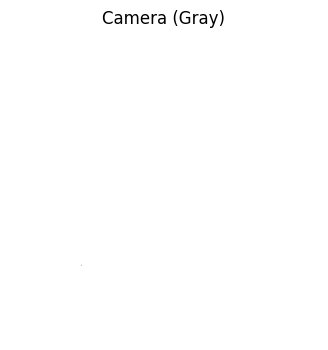

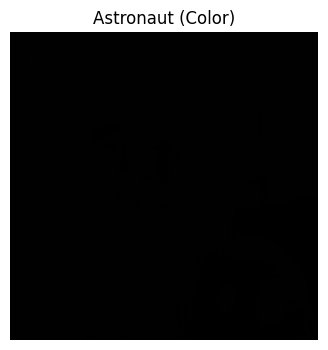

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['axes.grid'] = False

def show(img, title=None, cmap=None):
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or 'gray', vmin=0, vmax=1)
    else:
        plt.imshow(np.clip(img,0,1))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def to_float01(img):
    img = img.astype(np.float32)
    if img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]  # drop alpha
    if img.max() > 1.0:
        img = img / 255.0
    return np.clip(img, 0, 1)

def load_samples_or_demo():
    from skimage import data
    imgs = {
            'camera_gray': to_float01(data.camera()),
            'astronaut':   to_float01(data.astronaut()),
            'coffee':      to_float01(data.coffee()),
    }
    return imgs

imgs = load_samples_or_demo()
camera = imgs['camera_gray']  # 2D
astronaut = imgs['astronaut'] # 3D RGB
coffee = imgs['coffee']       # 3D RGB

show(camera, "Camera (Gray)")
show(astronaut, "Astronaut (Color)")